In [2]:
import netCDF4 as nc
import numpy as np
import pandas as pd

In [3]:
ds = nc.Dataset(r"D:\Acads\Analystics and software\Projects\2. SST PREDICTION USING LSTM\data\Raw\sst.mnmean.nc", "r")
print(ds.variables.keys())
print(ds.dimensions)

dict_keys(['lat', 'lon', 'time_bnds', 'time', 'sst'])
{'lat': <class 'netCDF4._netCDF4.Dimension'>: name = 'lat', size = 89, 'lon': <class 'netCDF4._netCDF4.Dimension'>: name = 'lon', size = 180, 'time': <class 'netCDF4._netCDF4.Dimension'> (unlimited): name = 'time', size = 2064, 'nbnds': <class 'netCDF4._netCDF4.Dimension'>: name = 'nbnds', size = 2}


In [ ]:
# reference of latitude and longitude
r'data/Raw/Latitude-and-Longitude-1024x683.png'

data/Raw/Latitude-and-Longitude-1024x683.png


In [4]:
lat  = ds.variables["lat"][:]
lon  = ds.variables["lon"][:]
sst  = ds.variables["sst"][:]
time = ds.variables["time"]

print("SST shape:", sst.shape)
print("Lat:", lat.min(), lat.max())
print("Lon:", lon.min(), lon.max())
print("Time units:", time.units)

SST shape: (2064, 89, 180)
Lat: -88.0 88.0
Lon: 0.0 358.0
Time units: days since 1800-1-1 00:00:00


In [10]:
print("SST sample data:", sst[0, 0, :5])

SST sample data: [-1.7999999523162842 -1.7999999523162842 -1.7999999523162842
 -1.7999999523162842 -1.7999999523162842]


# since the date is in the format of "days since 1850-01-01", we can convert it to datetime format

In [5]:
from netCDF4 import num2date
dates = num2date(time[:], units=time.units, calendar="standard")
dates = pd.to_datetime([str(d) for d in dates])
print(dates[:5])

DatetimeIndex(['1854-01-01', '1854-02-01', '1854-03-01', '1854-04-01',
               '1854-05-01'],
              dtype='datetime64[ns]', freq=None)


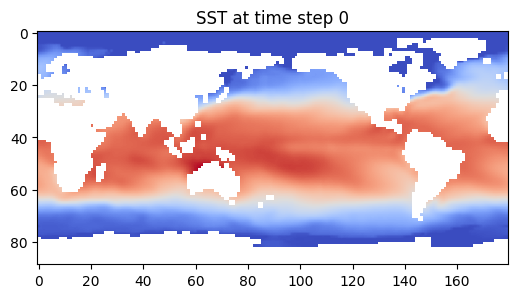

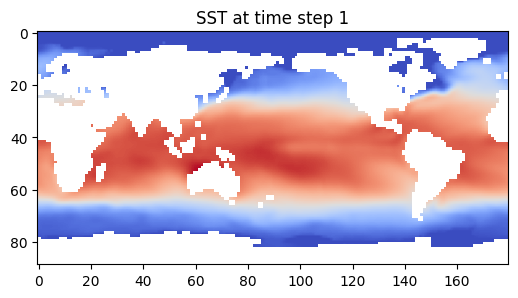

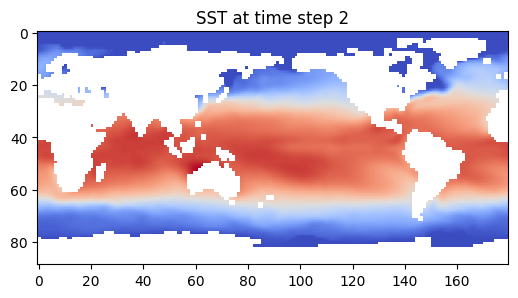

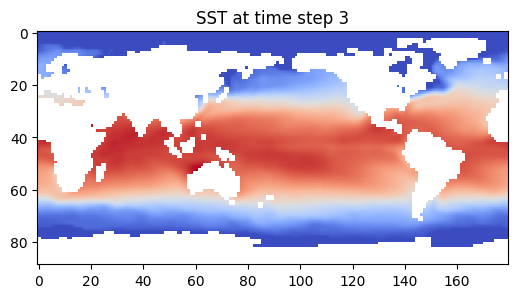

In [44]:
import matplotlib.pyplot as plt
reg=4
for i in range(reg):
    plt.figure(figsize=(20, 50))
    plt.subplot(i+1, reg, 1)
    plt.imshow(sst[i], origin="upper",cmap='coolwarm')
    plt.title(f"SST at time step {i}")
    plt.tight_layout()


In [ ]:
print('sample latitude:', lat[:10])
print('sample longitude:', lon[:10])


sample latitude: [88. 86. 84. 82. 80. 78. 76. 74. 72. 70.]
sample longitude: [ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]


In [25]:
# Trying Indian Ocean manually
lat_min, lat_max = -30, 30
lon_min, lon_max = 40, 120

lat_mask = (lat >= lat_min)&(lat <= lat_max)
lon_mask = (lon >= lon_min)&(lon <= lon_max)

lon_mask

masked_array(data=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False,

In [29]:
sst_region = sst[:, lat_mask, :] # enters only true latitudes which are 30S to 30N
sst_region = sst_region[:, :, lon_mask] # enters only true longitudes which are 40E to 120E
print("Region shape before filtering:", sst.shape)
print("Region shape after filtering:", sst_region.shape)

#selecting lat and then long to avoid missmatch in dimensions

Region shape before filtering: (2064, 89, 180)
Region shape after filtering: (2064, 31, 41)


Time series shape: (2064,)


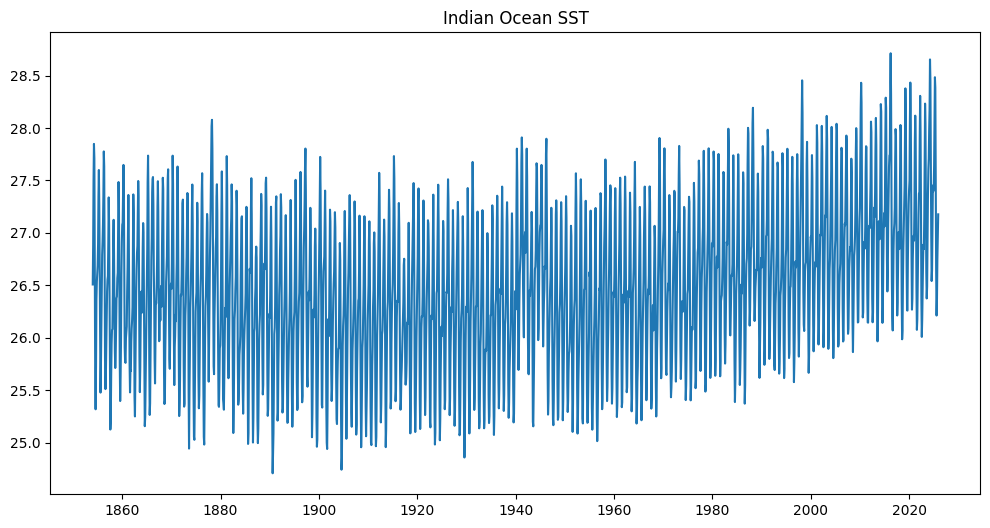

In [ ]:
sst_mean = np.nanmean(sst_region, axis=(1, 2)) #collapsing lat and long dimensions to get mean SST for each time
print("Time series shape:", sst_mean.shape)
plt.figure(figsize=(12, 6))
plt.plot(dates, sst_mean)
plt.title("Indian Ocean SST")
plt.show()

In [52]:
df = pd.DataFrame({"sst": sst_mean}, index=dates)
df.index.name = "date"
print(df.head())
print('----------------------')
print(df.describe())

                  sst
date                 
1854-01-01  26.508120
1854-02-01  26.886690
1854-03-01  27.489079
1854-04-01  27.848181
1854-05-01  27.709658
----------------------
               sst
count  2064.000000
mean     26.486025
std       0.754047
min      24.708010
25%      25.927314
50%      26.456066
75%      27.054342
max      28.712294


In [53]:
print("Missing:", df["sst"].isna().sum())
df["sst"] = df["sst"].interpolate(method="linear").ffill().bfill()
print("After fix:", df["sst"].isna().sum())

Missing: 0
After fix: 0


In [57]:
month = df.index.month
month

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
      dtype='int32', name='date', length=2064)

The model thinks December (12) and January (1) are 11 units apart but seasonally they are 1 month apart. The number line doesn't wrap around.

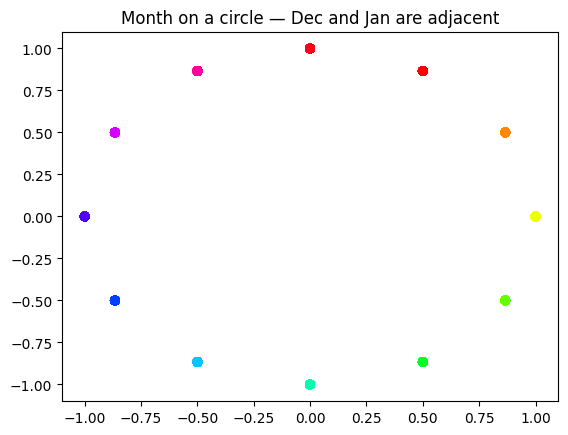

In [54]:
# Why not just use month number?
# Because model thinks Dec(12) and Jan(1) are far apart — they're not!
month = df.index.month
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

plt.scatter(df["month_sin"], df["month_cos"], c=month, cmap="hsv")
plt.title("Month on a circle — Dec and Jan are adjacent")
plt.show()